# 07 · mask의 예측 latency와 실제 읽기 시간

## 질문

per-chunk 비용의 합이 실제 혼합 mask 읽기 시간을 설명하는가? 좋은 I/O mask를 만드는 데 걸리는 selector 시간이 그 이득을 지우는가? batch로 얻은 $T$를 개별 read의 물리 법칙처럼 취급하지 않고 검증한다.

$$\hat L(M)=\sum_{C\in\mathcal R(M)}\hat T(|C|),\qquad
W_p(M)=\operatorname{walltime}(\text{all requests of }M;\ p\text{ workers}).$$

가산 모델과 병렬 실행의 차이를 이해하기 위한 이상적인 scheduling bound는

$$\max\{\max_j\tau_j,\;p^{-1}\sum_j\tau_j\}\le\operatorname{makespan}\le\sum_j\tau_j.$$

이는 독립 job service time $\tau_j$를 가정한 bound다. SSD에서 service time 자체가 concurrency에 따라 변할 수 있으므로 측정 $T$를 바로 $\tau$에 넣어 hardware bound라고 선언하지 않는다.

## 독립 calibration과 validation

이번 실행에서 새 512 MiB 파일로 길이별 profile을 측정한다. 새로운 importance로 여러 $R$과 방법의 mask를 만든 뒤, **별도의 새 128 MiB 파일**에서 각 최대 run을 한 개의 aligned request로 바꾸어 실행한다. 1 worker와 4 workers를 각각 측정하며 모든 method×budget 조합의 순서를 반복마다 무작위화한다. buffer warmup 후 9회 반복의 원시 시간을 보존한다.

mask는 $n=256$, row size 4096 byte로 모두 정렬된다. 실험 범위에서 run은 최대 1 MiB이므로 request splitting은 필요하지 않다. 파일 내 base offset도 반복마다 바꾸어 하나의 주소에만 종속되는 결과를 줄인다. page cache는 O_DIRECT로 우회하지만 장치 cache·다른 프로세스·온도·전력 상태는 통제했다고 주장하지 않는다.

## fit과 진단

$$W(M)\approx\alpha\hat L(M),\qquad
W(M)\approx\beta+\alpha\hat L(M).$$

예산의 앞 절반 mask로 $\alpha,\beta$를 fit하고 뒤 절반의 다른 mask로 검증한다. 같은 mask의 다른 반복만 holdout으로 쓰는 것보다 강한 분할이다. holdout RMSE와 $(\hat L,W)$ scatter, residual 대 run 수를 출력한다. proportional bias가 모든 mask에 일정하면 ratio 순위는 보존되지만, mask별 오차나 절편이 있으면 그런 결론은 자동으로 나오지 않는다.

$$\frac{I}{\alpha L}=\alpha^{-1}\frac IL,\qquad
\frac{I}{\alpha L+\beta}\text{ 는 }\frac IL\text{ 와 같은 순위를 보장하지 않는다.}$$

## 실제로 측정하는 총 비용

$$H(M)=S(M)+W_p(M).$$

$S$는 importance와 cost table이 이미 메모리에 있을 때 **선택 함수 전체**의 CPU 시간이다. prefix sum·후보 생성·정렬·mask 구성을 포함한다. profiling은 offline 비용으로 제외한다. $H$는 selector+I/O subtotal이며 GPU upload, gather, GEMM, 전체 모델 추론 시간은 포함하지 않는다.

runtime은 이 노트북의 Python 구현에 한정한다. 논문의 C++/GPU 구현보다 빠르거나 느리다는 주장은 하지 않는다. 다른 구현 비용을 공정하게 비교하려면 같은 backend가 필요하다.

## 출력

예측–실측 관계, workers에 따른 변화, held-out 오차, $S$와 $W$의 누적 막대, retained importance 대 $H$를 표시한다. 동일 $R$의 I/O 비교와 importance가 다른 방법의 utility 비교를 함께 둔다. 값이 기대와 반대여도 수동으로 결론을 고치지 않고 실행 결과에 그대로 남긴다.


## 실행 설정과 provenance

Run All은 새로운 계산·측정을 수행하고 고유 run 디렉토리를 만듭니다.

In [1]:
from pathlib import Path
import json
import sys
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p / "conclusion_september" for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "conclusion_september/core.py").exists())
sys.path.insert(0, str(ROOT))
import core as C
from reporting import begin, figure, finish
SEED = 20260926
rng = np.random.default_rng(SEED)
RUN = begin(ROOT, "07_mask_walltime", SEED)

**이번 실행:** `07_mask_walltime-20260926T043705-596388e6` · seed `20260926` · 새 계산/측정

## Calibration과 selector 시간 · 후보 구성 비용까지 측정

In [2]:
from measure import profile, cost_table, near_saturation, DirectReader, PAGE
n = 256
raw, hardware = profile(RUN, repeats=5, seed=SEED)
raw.to_csv(RUN / "io_raw.csv", index=False)
(RUN / "hardware.json").write_text(json.dumps(hardware, indent=2))
cost, s = cost_table(raw, n), near_saturation(raw)
v = C.workload(n, SEED, "spiky")
cases, selectors, timing = {}, {}, []
for r in [16, 32, 64, 96, 160, 224]:
    methods = {"Top-R": lambda r=r: C.topk(v, r),
               "Paper": lambda r=r: C.paper(v, r, cost, s),
               "Saturation": lambda r=r: C.saturation(v, r, cost, s)}
    for method, selector in methods.items():
        key = f"{method}|{r}"
        mask = selector()
        selectors[key] = selector
        cases[key] = dict(method=method, R=r, mask=mask, predicted=C.latency(mask, cost),
                          retained=v[mask].sum()/v.sum(), runs=len(C.runs(mask)))
keys = list(cases)
for repeat in range(9):
    for index in rng.permutation(len(keys)):
        key = keys[index]
        start = perf_counter()
        selectors[key]()
        timing.append(dict(case=key, repeat=repeat, selector_ms=1000*(perf_counter()-start)))
selector_frame = pd.DataFrame(timing)
selector_frame.to_csv(RUN / "selector_raw.csv", index=False)
selector_median = selector_frame.groupby("case").selector_ms.median()

## Validation · 별도의 새 파일에서 전체 mask를 직접 읽기

In [3]:
readings = []
for workers in [1, 4]:
    with DirectReader(RUN, workers=workers, seed=SEED + workers) as reader:
        reader.read([(i*n*PAGE, n*PAGE) for i in range(64)])
        for repeat in range(9):
            for index in rng.permutation(len(keys)):
                key = keys[index]
                case = cases[key]
                base = int(rng.integers(0, reader.size // PAGE - n)) * PAGE
                requests = [(base + int(a)*PAGE, int(b-a)*PAGE) for a, b in C.runs(case["mask"])]
                ms = reader.read(requests)
                readings.append(dict(case=key, method=case["method"], R=case["R"], workers=workers,
                                     repeat=repeat, wall_ms=ms, predicted=case["predicted"],
                                     retained=case["retained"], runs=case["runs"]))
wall = pd.DataFrame(readings)
wall.to_csv(RUN / "mask_io_raw.csv", index=False)
summary = wall.groupby(["case", "method", "R", "workers"], as_index=False).agg(
    wall_ms=("wall_ms", "median"), p10=("wall_ms", lambda x: x.quantile(.1)),
    p90=("wall_ms", lambda x: x.quantile(.9)), predicted=("predicted", "first"),
    retained=("retained", "first"), runs=("runs", "first"))
summary["selector_ms"] = summary["case"].map(selector_median)
summary["subtotal_ms"] = summary.wall_ms + summary.selector_ms
summary.to_csv(RUN / "mask_summary.csv", index=False)
fits = []
for workers, group in summary.groupby("workers"):
    train, test = group[group.R <= 64], group[group.R > 64]
    for kind in ["Proportional", "Affine"]:
        design = lambda x: np.column_stack([x, np.ones(len(x))]) if kind == "Affine" else np.array(x)[:, None]
        coef = np.linalg.lstsq(design(train.predicted), train.wall_ms, rcond=None)[0]
        prediction = design(test.predicted) @ coef
        fits.append(dict(workers=workers, model=kind, coefficients=coef.tolist(),
                         heldout_masks=len(test), rmse_ms=np.sqrt(np.mean((test.wall_ms-prediction)**2))))
display(pd.DataFrame(fits))
pd.DataFrame(fits).to_csv(RUN / "heldout_fits.csv", index=False)

,workers,model,coefficients,heldout_masks,rmse_ms
0,1,Proportional,[2.480637827600655],9,0.172401
1,1,Affine,"[2.4198505168924864, 0.053740345598194]",9,0.146223
2,4,Proportional,[0.987576643367205],9,0.270296
3,4,Affine,"[0.8471511643819273, 0.1241462022837388]",9,0.182316


## 관측 · model 오차와 selector+I/O 비용을 함께 표시

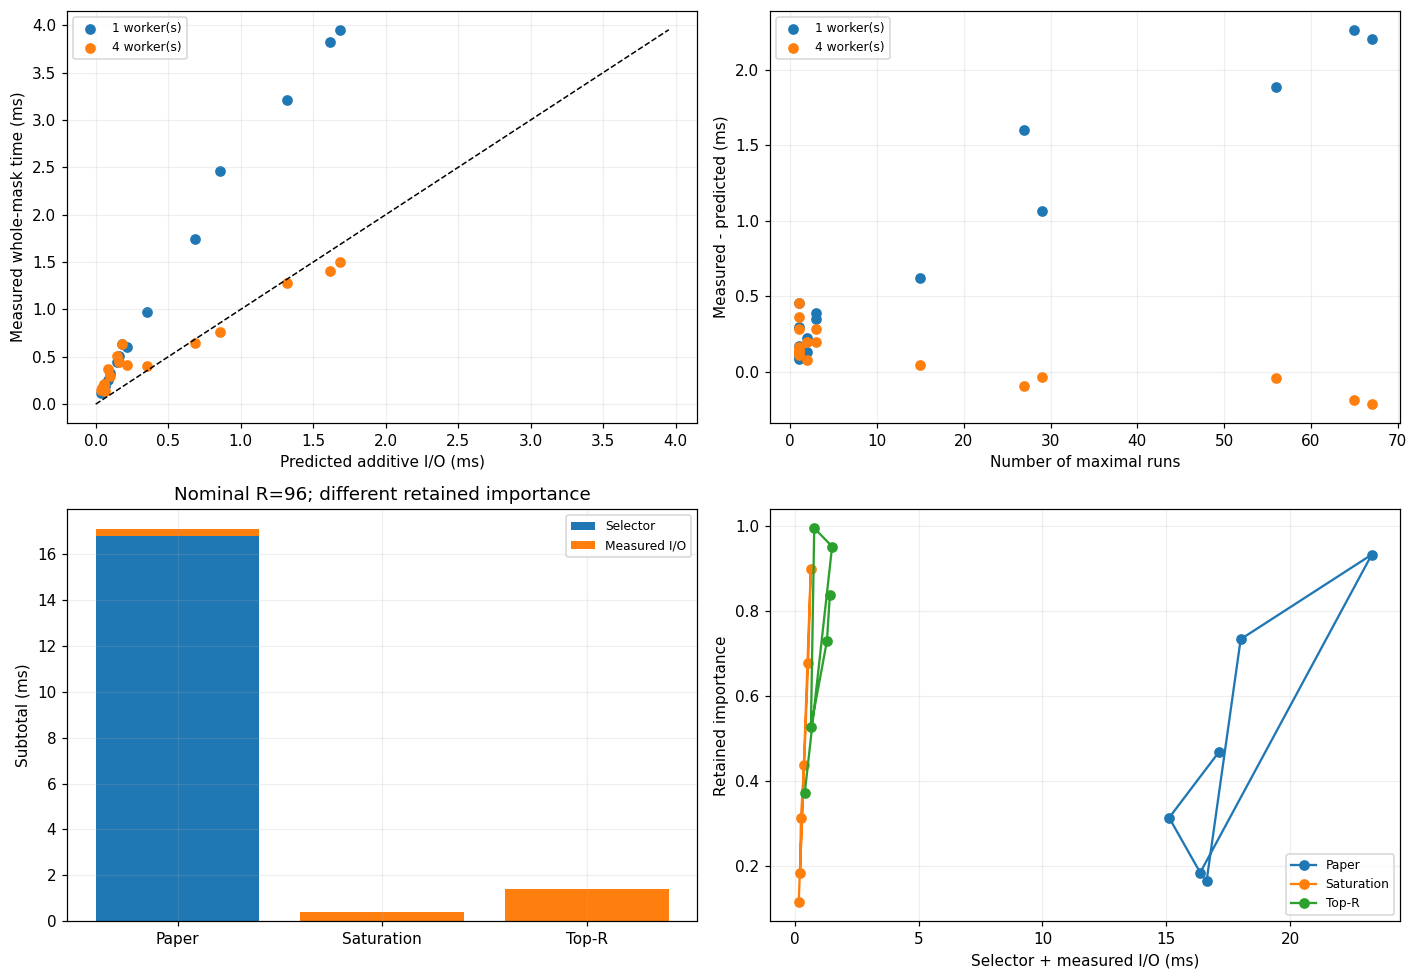

**실행에서 확인한 값**

- **physical_reads**: 324

- **mask_cases**: 18

- **near_best_pages**: 512

- **heldout_fit_metrics**: [{'workers': 1, 'model': 'Proportional', 'coefficients': [2.480637827600655], 'heldout_masks': 9, 'rmse_ms': np.float64(0.17240113474478871)}, {'workers': 1, 'model': 'Affine', 'coefficients': [2.4198505168924864, 0.053740345598194], 'heldout_masks': 9, 'rmse_ms': np.float64(0.14622337852754408)}, {'workers': 4, 'model': 'Proportional', 'coefficients': [0.987576643367205], 'heldout_masks': 9, 'rmse_ms': np.float64(0.2702957402001779)}, {'workers': 4, 'model': 'Affine', 'coefficients': [0.8471511643819273, 0.1241462022837388], 'heldout_masks': 9, 'rmse_ms': np.float64(0.1823163896551738)}]

- **scope**: Actual direct-I/O and Python selector subtotal; excludes GPU transfer, GEMM and task inference

- **completed_utc**: 2026-09-26T04:37:11.271057+00:00

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for workers, group in summary.groupby("workers"):
    axes[0, 0].scatter(group.predicted, group.wall_ms, label=f"{workers} worker(s)")
    axes[0, 1].scatter(group.runs, group.wall_ms-group.predicted, label=f"{workers} worker(s)")
limit = max(summary.predicted.max(), summary.wall_ms.max())
axes[0, 0].plot([0, limit], [0, limit], "k--", lw=1)
axes[0, 0].set(xlabel="Predicted additive I/O (ms)", ylabel="Measured whole-mask time (ms)")
axes[0, 1].set(xlabel="Number of maximal runs", ylabel="Measured - predicted (ms)")
selected = summary[(summary.workers == 4) & (summary.R == 96)]
axes[1, 0].bar(selected.method, selected.selector_ms, label="Selector")
axes[1, 0].bar(selected.method, selected.wall_ms, bottom=selected.selector_ms, label="Measured I/O")
axes[1, 0].set(ylabel="Subtotal (ms)", title="Nominal R=96; different retained importance")
for method, group in summary[summary.workers == 4].groupby("method"):
    axes[1, 1].plot(group.subtotal_ms, group.retained, "o-", label=method)
axes[1, 1].set(xlabel="Selector + measured I/O (ms)", ylabel="Retained importance")
for ax in axes.flat:
    ax.legend(fontsize=8)
figure(RUN, "physical_mask_validation")
finish(RUN, physical_reads=len(wall), mask_cases=len(cases), near_best_pages=s,
       heldout_fit_metrics=fits,
       scope="Actual direct-I/O and Python selector subtotal; excludes GPU transfer, GEMM and task inference")